In [13]:
import torch
from torch import nn
from torch.nn import functional as F
from d2l import torch as d2l
import sys
import os
import math

# 将上级目录添加到 sys.path，以便导入 d2l_utils
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
import d2l_utils

# 批量大小和时间步数
batch_size, num_steps = 32, 35
# 加载时光机器数据集
# train_iter: 数据迭代器
# vocab: 词表
# 使用本地 d2l_utils 中的 load_data_time_machine 加载时光机器数据集
train_iter, vocab = d2l_utils.load_data_time_machine(batch_size, num_steps)

In [14]:
# 定义隐藏层单元数
num_hiddens = 256
# 定义RNN层
# len(vocab): 输入特征维度（即词表大小，因为使用one-hot编码）
# num_hiddens: 隐藏层输出维度
# 修改：使用 GRU 替换 RNN，以缓解梯度消失问题，提高模型性能
rnn_layer = nn.GRU(len(vocab), num_hiddens)

In [15]:
# 初始化隐藏状态
# 形状: (隐藏层层数 * 方向数, 批量大小, 隐藏单元数)
state = torch.zeros((1, batch_size, num_hiddens))
print(f"Initial state shape: {state.shape}")

Initial state shape: torch.Size([1, 32, 256])


In [16]:
# 创建一个随机输入张量进行测试
# 形状: (时间步数, 批量大小, 词表大小)
X = torch.rand(size=(num_steps, batch_size, len(vocab)))
# 前向传播
# Y: 输出，形状 (时间步数, 批量大小, 隐藏单元数)
# state_new: 更新后的隐藏状态
Y, state_new = rnn_layer(X, state)
print(f"Output Y shape: {Y.shape}, New state shape: {state_new.shape}")

Output Y shape: torch.Size([35, 32, 256]), New state shape: torch.Size([1, 32, 256])


In [17]:
#@save
class RNNModel(nn.Module):
    """循环神经网络模型"""
    def __init__(self, rnn_layer, vocab_size, **kwargs):
        super(RNNModel, self).__init__(**kwargs)
        self.rnn = rnn_layer
        self.vocab_size = vocab_size
        self.num_hiddens = self.rnn.hidden_size
        # 如果RNN是双向的（之后将介绍），num_directions应该是2，否则应该是1
        if not self.rnn.bidirectional:
            self.num_directions = 1
            self.linear = nn.Linear(self.num_hiddens, self.vocab_size)
        else:
            self.num_directions = 2
            self.linear = nn.Linear(self.num_hiddens * 2, self.vocab_size)

    def forward(self, inputs, state):
        # inputs 形状: (批量大小, 时间步数)
        # 转置后形状: (时间步数, 批量大小)
        # one_hot 编码后形状: (时间步数, 批量大小, 词表大小)
        X = F.one_hot(inputs.T.long(), self.vocab_size)
        X = X.to(torch.float32)

        # RNN 前向传播
        # Y 形状: (时间步数, 批量大小, 隐藏单元数)
        # state 形状: (层数 * 方向数, 批量大小, 隐藏单元数)
        Y, state = self.rnn(X, state)

        # 全连接层首先将Y的形状改为(时间步数 * 批量大小, 隐藏单元数)
        # 它的输出形状是(时间步数 * 批量大小, 词表大小)。
        output = self.linear(Y.reshape((-1, Y.shape[-1])))
        return output, state

    def begin_state(self, device, batch_size=1):
        # 初始化隐藏状态
        if not isinstance(self.rnn, nn.LSTM):
            # nn.GRU以张量作为隐状态
            return  torch.zeros((self.num_directions * self.rnn.num_layers,
                                 batch_size, self.num_hiddens),
                                device=device)
        else:
            # nn.LSTM以元组作为隐状态
            return (torch.zeros((
                self.num_directions * self.rnn.num_layers,
                batch_size, self.num_hiddens), device=device),
                    torch.zeros((
                        self.num_directions * self.rnn.num_layers,
                        batch_size, self.num_hiddens), device=device))


In [18]:
# Prediction
def predict_ch8(prefix, num_preds, net, vocab, device):
    """在 `prefix` 后面生成新字符"""
    # 初始化隐藏状态，batch_size 为 1
    state = net.begin_state(batch_size=1, device=device)
    # 将 prefix 的第一个字符转换为索引
    outputs = [vocab[prefix[0]]]
    # 定义一个 lambda 函数，用于获取最新的输入（上一个预测的字符）
    get_input = lambda: torch.tensor([outputs[-1]], device=device).reshape((1, 1))
    # 预热期：使用 prefix 中的字符更新隐藏状态，但不记录输出
    for y in prefix[1:]:
        _, state = net(get_input(), state)
        outputs.append(vocab[y])
    # 预测期：生成 num_preds 个新字符
    for _ in range(num_preds):
        # 使用上一个字符和当前状态进行预测
        y, state = net(get_input(), state)
        # 将预测结果（概率最大的索引）添加到 outputs
        outputs.append(int(y.argmax(dim=1).reshape(1)))
    # 将索引转换回字符并拼接成字符串
    return ''.join([vocab.idx_to_token[i] for i in outputs])


In [19]:
# Gradient Clipping
def grad_clipping(net, theta):
    """梯度裁剪，防止梯度爆炸"""
    if isinstance(net, nn.Module):
        params = [p for p in net.parameters() if p.requires_grad]
    else:
        params = net.params
    # 计算所有参数梯度的 L2 范数
    norm = torch.sqrt(sum(torch.sum((p.grad ** 2)) for p in params))
    # 如果范数超过阈值 theta，则按比例缩小梯度
    if norm > theta:
        for param in params:
            param.grad[:] *= theta / norm


In [20]:
# Training
def train_epoch_ch8(net, train_iter, loss, updater, device, use_random_iter):
    """训练网络一个迭代周期"""
    state, timer = None, d2l.Timer()
    metric = d2l.Accumulator(2)  # 累加器：训练损失之和，词元数量
    for X, Y in train_iter:
        if state is None or use_random_iter:
            # 如果是第一次迭代或使用随机抽样，初始化状态
            state = net.begin_state(batch_size=X.shape[0], device=device)
        else:
            # 否则，分离状态以切断计算图，防止梯度反向传播到之前的批次
            if isinstance(net, nn.Module) and not isinstance(state, tuple):
                state.detach_()
            else:
                for s in state:
                    s.detach_()
        # 将标签 Y 转置并展平
        y = Y.T.reshape(-1)
        X, y = X.to(device), y.to(device)
        # 前向传播
        y_hat, state = net(X, state)
        # 计算损失
        l = loss(y_hat, y.long()).mean()
        if isinstance(updater, torch.optim.Optimizer):
            updater.zero_grad()
            l.backward()
            grad_clipping(net, 1) # 梯度裁剪
            updater.step()
        else:
            l.backward()
            grad_clipping(net, 1) # 梯度裁剪
            # 因为已经调用了 mean 函数，所以 batch_size 传 1
            updater(batch_size=1)
        metric.add(l * y.numel(), y.numel())
    # 返回困惑度（perplexity）和每秒处理的词元数
    return math.exp(metric[0] / metric[1]), metric[1] / timer.stop()

def train_ch8(net, train_iter, vocab, lr, num_epochs, device,
              use_random_iter=False):
    """训练模型"""
    loss = nn.CrossEntropyLoss()
    # 动画绘制器，用于实时显示训练进度
    # 注意：这里使用了 d2l_utils 中的 Animator，如果 d2l_utils 中没有，可能需要从 d2l.torch 导入或自定义
    # 假设 d2l_utils 中有 Animator，或者 d2l.Animator 可用
    # 检查 d2l_utils.py 发现有 Animator 类，但这里我们先尝试用 d2l.Animator，如果报错再改
    # 实际上 d2l_utils.py 里有 Animator 类，我们可以用 d2l_utils.Animator
    animator = d2l_utils.Animator(xlabel='epoch', ylabel='perplexity',
                            legend=['train'], xlim=[10, num_epochs])
    # 初始化优化器
    if isinstance(net, nn.Module):
        updater = torch.optim.SGD(net.parameters(), lr)
    else:
        updater = lambda batch_size: d2l.sgd(net.params, lr, batch_size)
    # 定义预测函数，用于在训练过程中观察生成效果
    predict = lambda prefix: predict_ch8(prefix, 50, net, vocab, device)
    # 训练循环
    ppl, speed = 0.0, 0.0
    for epoch in range(num_epochs):
        ppl, speed = train_epoch_ch8(
            net, train_iter, loss, updater, device, use_random_iter)
        # 每 10 个 epoch 打印一次预测结果并更新图表
        if (epoch + 1) % 10 == 0:
            print(predict('time traveller'))
            animator.add(epoch + 1, [ppl])
    print(f'perplexity {ppl:.1f}, {speed:.1f} tokens/sec on {str(device)}')
    print(predict('time traveller'))
    print(predict('traveller'))


In [21]:
# 获取设备（GPU或CPU）
device = d2l.try_gpu()
# 实例化模型
net = RNNModel(rnn_layer, vocab_size=len(vocab))
net = net.to(device)
# 预测测试
# 预测 'time traveller' 之后的 10 个字符
# 使用本地定义的 predict_ch8
predict_ch8('time traveller', 10, net, vocab, device)

'time travellerooooodoood'

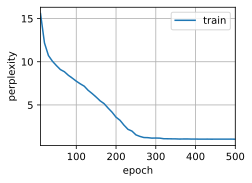

In [22]:
# 训练参数设置
num_epochs, lr = 500, 1
# 开始训练
# 使用本地定义的 train_ch8
train_ch8(net, train_iter, vocab, lr, num_epochs, device)